In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [18]:
# Import dataset and reading
ds=pd.read_csv("Social_Network_Ads.csv")

In [19]:
ds.columns

Index(['Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [20]:
ds.duplicated().sum()

np.int64(33)

In [21]:
# Removing Duplicat
ds.drop_duplicates(inplace=True)

In [22]:
# Finding missing Values
ds.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [23]:
#Spliting as Indipedent and depedent variabls
x=ds[['Age','EstimatedSalary']]
y=ds[['Purchased']]

In [24]:
# Frature scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x=pd.DataFrame(sc.fit_transform(x),columns=['Age','EstimatedSalary'])

In [25]:
# Spliting the dataset into the training set and test set
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=0)

In [26]:
x_train

,Age,EstimatedSalary
132,-0.723934,1.044806
264,-0.067693,-0.020716
64,-1.286426,-1.489408
206,0.213553,0.209667
303,0.963542,1.735956
...,...,...
323,1.526034,1.073604
192,0.307301,0.008082
117,0.213553,0.123274
47,-0.723934,1.851147


In [27]:
#applying the Logisitic regression model
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression()
classifier.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [28]:
#predict for myinput
myinput=pd.DataFrame(sc.transform([[30,150000]]),columns=['Age','EstimatedSalary'])
classifier.predict(myinput)

array([0])

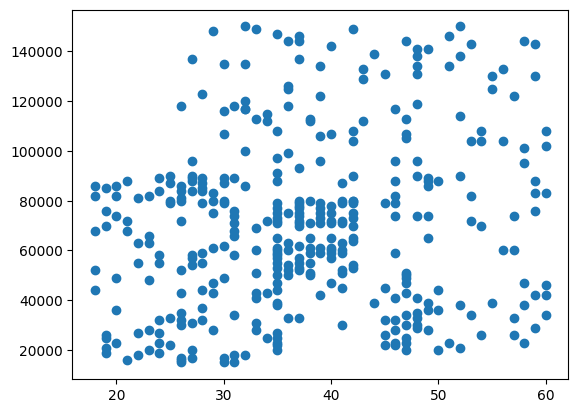

In [30]:
#Visulation
# Visualization 

original_x = pd.DataFrame(sc.inverse_transform(x), columns =  ['Age', 'EstimatedSalary'])
plt.scatter(original_x["Age"], original_x["EstimatedSalary"])
plt.show()


In [23]:
#Cheaking Accuracy of Logistic regression model
from sklearn.metrics import accuracy_score

#Predict on the set test set 
y_pred=classifier.predict(x_test)

#calculate accuray
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy of the lositstic meodel:{accuracy * 100:.2f}%")

Accuracy of the lositstic meodel:83.78%


In [16]:
# User Input
age=float(input("enter age:"))
salary=float(input("enter estimated salary:"))
myinput=pd.DataFrame(sc.transform([[age,salary]]),columns=['Age','EstimatedSalary'])
result=classifier.predict(myinput)
if result[0] == 1:
    print("Prediction: User will purchase plan")
else:
    print("Prediction: User will not purchase plan")
    

enter age: 21
enter estimated salary: 50000


Prediction: User will not purchase plan


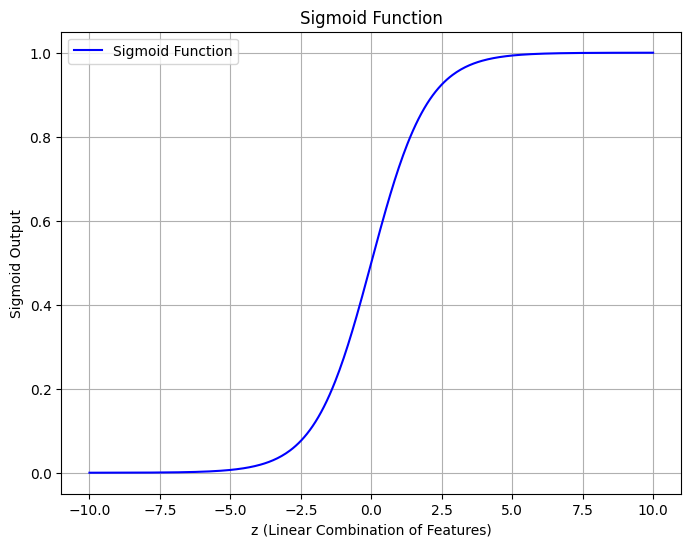

In [31]:
# Sigmoid Function

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


# 1. Plot the sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 400)
sigmoid_values = sigmoid(z)

plt.figure(figsize=(8, 6))
plt.plot(z, sigmoid_values, label="Sigmoid Function", color="b")
plt.title("Sigmoid Function")
plt.xlabel("z (Linear Combination of Features)")
plt.ylabel("Sigmoid Output")
plt.grid(True)
plt.legend()
plt.show()